<a href="https://colab.research.google.com/github/LenaGeller/Disaster-Tweet-Classification-NLP/blob/main/Loan_Approval_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Overview

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Mock Intw Loan Dataset/'
data = pd.read_csv(path + "loans_modified.csv")
print(data.shape)
data.head(10)

(563, 13)


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0.0
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban,1.0
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1.0
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1.0
4,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1.0
5,LP001013,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban,1.0
6,LP001014,Male,Yes,3+,Graduate,No,3036.0,2504.0,158.0,360.0,0.0,NaN,0.0
7,LP001018,Male,Yes,2,Graduate,No,4006.0,1526.0,168.0,360.0,1.0,NaN,1.0
8,LP001020,Male,Yes,1,Graduate,No,12841.0,10968.0,349.0,360.0,1.0,Semiurban,0.0
9,LP001024,Male,Yes,2,Graduate,No,3200.0,700.0,70.0,360.0,1.0,Urban,1.0


In [ ]:
print(data.shape)
print(data.drop_duplicates().shape)



(563, 13)
(538, 13)


# EDA

## NaN Values

In [ ]:
print(data.isnull().sum())

loan_id               29
gender                29
married               19
dependents            32
education             22
self_employed         34
applicant_income      26
coapplicant_income    34
loan_amount           30
loan_amount_term      28
credit_history        22
property_area         21
loan_status           28
dtype: int64


Let’s examin the NaN values in detail.

In [ ]:
nan_rows = data[data.isna().any(axis=1)]

print(nan_rows.isna().sum(axis=1).value_counts().head())


1    209
2     52
3     11
4      2
Name: count, dtype: int64


In [ ]:
many_nans = data[data.isna().sum(axis=1) >= 3]

print(f"Anzahl Zeilen mit >=3 NaNs: {many_nans.shape[0]}")
display(many_nans)


Anzahl Zeilen mit >=3 NaNs: 13


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
65,NaN,Male,NaN,3+,NaN,Yes,5266.0,1774.0,187.0,360.0,1.0,Semiurban,1.0
119,LP001498,NaN,No,0,Graduate,No,5417.0,NaN,168.0,NaN,1.0,Urban,1.0
211,NaN,Male,Yes,1,Graduate,No,NaN,1843.0,123.0,NaN,1.0,Semiurban,1.0
234,NaN,Male,Yes,0,Graduate,No,11146.0,0.0,136.0,NaN,NaN,Urban,1.0
284,LP002086,NaN,Yes,0,Graduate,No,NaN,2451.0,NaN,360.0,1.0,Urban,0.0
287,NaN,Male,No,0,Graduate,No,2935.0,0.0,NaN,360.0,NaN,Semiurban,1.0
330,LP002234,Male,No,0,Graduate,NaN,7167.0,NaN,NaN,360.0,1.0,Urban,1.0
332,LP002237,Male,No,NaN,NaN,No,3667.0,NaN,113.0,180.0,NaN,Urban,1.0
440,NaN,Male,Yes,2,Graduate,No,3510.0,4416.0,243.0,360.0,1.0,NaN,NaN
510,LP002898,Male,Yes,1,NaN,No,1880.0,NaN,61.0,NaN,1.0,NaN,0.0


In a dataset used to decide whether a loan should be approved, any row where LoanAmount or Loan_Amount_Term is missing or zero must be treated as invalid and removed, since the absence of both values means the loan itself is undefined.

In [ ]:
print("Gesamt vor Filter:", data.shape[0])

mask_invalid = (data["loan_amount"].isna() | (data["loan_amount"] <= 0)) | \
               (data["loan_amount_term"].isna() | (data["loan_amount_term"] <= 0))

print("Anzahl ungültige Zeilen:", mask_invalid.sum())

data = data[~mask_invalid].copy()

print("Gesamt nach Filter:", data.shape[0])


Gesamt vor Filter: 563
Anzahl ungültige Zeilen: 56
Gesamt nach Filter: 507


In [ ]:
data = data.reset_index(drop=True)
data['loan_id'] = data.index + 1


In [ ]:
data.dtypes

,0
loan_id,int64
gender,object
married,object
dependents,object
education,object
self_employed,object
applicant_income,float64
coapplicant_income,float64
loan_amount,float64
loan_amount_term,float64


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             507 non-null    int64  
 1   gender              482 non-null    object 
 2   married             489 non-null    object 
 3   dependents          476 non-null    object 
 4   education           486 non-null    object 
 5   self_employed       476 non-null    object 
 6   applicant_income    487 non-null    float64
 7   coapplicant_income  478 non-null    float64
 8   loan_amount         507 non-null    float64
 9   loan_amount_term    507 non-null    float64
 10  credit_history      489 non-null    float64
 11  property_area       489 non-null    object 
 12  loan_status         479 non-null    float64
dtypes: float64(6), int64(1), object(6)
memory usage: 51.6+ KB



Distribution of loan status:
loan_status
1.0    348
0.0    131
Name: count, dtype: int64


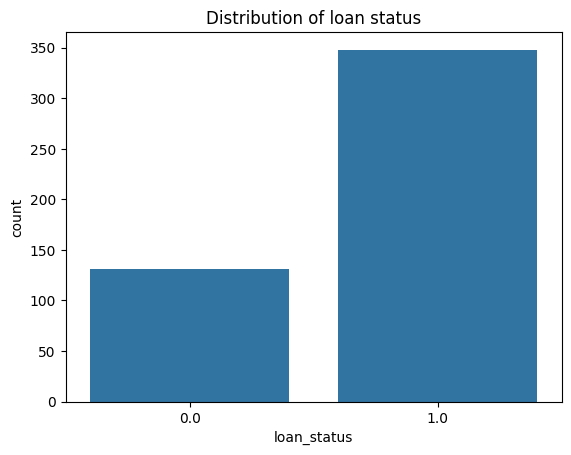

In [ ]:
print('\nDistribution of loan status:')
print(data['loan_status'].value_counts())
sns.countplot(x='loan_status', data=data)
plt.title('Distribution of loan status')
plt.show()

In [ ]:
data.describe()

,loan_id,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status
count,507.00000,487.000000,478.000000,507.000000,507.000000,489.000000,479.000000
mean,254.00000,5415.310062,1723.767615,148.169625,342.982249,0.883436,0.726514
std,146.50256,6273.702610,3201.832695,87.461605,62.639234,0.321229,0.446214
min,1.00000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,127.50000,2891.500000,0.000000,100.000000,360.000000,1.000000,0.000000
50%,254.00000,3762.000000,1252.500000,128.000000,360.000000,1.000000,1.000000
75%,380.50000,5817.000000,2333.000000,172.500000,360.000000,1.000000,1.000000
max,507.00000,81000.000000,41667.000000,650.000000,480.000000,1.000000,1.000000


## Train/Test Split

In [ ]:
data = data.dropna(subset=["loan_status"])

X = data.drop(columns=["loan_status", "loan_id"])
y = data["loan_status"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nVerteilung Loan Status gesamt:")
print(y.value_counts(normalize=True))
print("\nVerteilung Train:")
print(y_train.value_counts(normalize=True))
print("\nVerteilung Test:")
print(y_test.value_counts(normalize=True))


Train shape: (383, 11) (383,)
Test shape: (96, 11) (96,)

Verteilung Loan Status gesamt:
loan_status
1.0    0.726514
0.0    0.273486
Name: proportion, dtype: float64

Verteilung Train:
loan_status
1.0    0.725849
0.0    0.274151
Name: proportion, dtype: float64

Verteilung Test:
loan_status
1.0    0.729167
0.0    0.270833
Name: proportion, dtype: float64


## Encoding

In [ ]:
print(data.columns)


Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicant_income', 'coapplicant_income',
       'loan_amount', 'loan_amount_term', 'credit_history', 'property_area',
       'loan_status'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd

X_train = X_train.copy()
X_test  = X_test.copy()

bin_maps = {
    "gender": {"Male": 1, "Female": 0},
    "married": {"Yes": 1, "No": 0},
    "education": {"Graduate": 1, "Not Graduate": 0},
    "self_employed": {"Yes": 1, "No": 0},
}
for col, m in bin_maps.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].map(m).astype("float")

    if col in X_test.columns:
        X_test[col] = X_test[col].map(m).astype("float")

print(X_train.head())


     gender  married dependents  education  self_employed  applicant_income  \
382     1.0      0.0          0        0.0            NaN            2699.0   
67      1.0      NaN         3+        0.0            1.0            3333.0   
122     1.0      1.0          1        1.0            0.0            9538.0   
401     1.0      1.0          1        1.0            0.0            6065.0   
58      1.0      1.0         3+        0.0            1.0            7100.0   

     coapplicant_income  loan_amount  loan_amount_term  credit_history  \
382              2785.0         96.0             360.0             1.0   
67               2166.0        130.0             360.0             1.0   
122                 0.0        187.0             360.0             1.0   
401              2004.0        250.0             360.0             1.0   
58                  0.0        125.0              60.0             1.0   

    property_area  
382     Semiurban  
67      Semiurban  
122         Urban  


In [ ]:
if "property_area" in X_train.columns:
    dmy_train = pd.get_dummies(
        X_train["property_area"], prefix="property_area", drop_first=True, dtype=np.int8
    )
    dmy_test = pd.get_dummies(
        X_test["property_area"],  prefix="property_area", drop_first=True, dtype=np.int8
    )

    dmy_test = dmy_test.reindex(columns=dmy_train.columns, fill_value=0)

    X_train = X_train.drop(columns=["property_area"]).join(dmy_train)
    X_test  = X_test.drop(columns=["property_area"]).join(dmy_test)


print("Train columns:", X_train.columns.tolist())
print("Test  columns:", X_test.columns.tolist())


Train columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'property_area_Semiurban', 'property_area_Urban']
Test  columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'property_area_Semiurban', 'property_area_Urban']


In [ ]:
print(X_train.dtypes)

for col in X_train.columns:
    print(f"{col:20} | dtype: {X_train[col].dtype} | unique: {X_train[col].nunique()}")


gender                     float64
married                    float64
dependents                  object
education                  float64
self_employed              float64
applicant_income           float64
coapplicant_income         float64
loan_amount                float64
loan_amount_term           float64
credit_history             float64
property_area_Semiurban       int8
property_area_Urban           int8
dtype: object
gender               | dtype: float64 | unique: 2
married              | dtype: float64 | unique: 2
dependents           | dtype: object | unique: 4
education            | dtype: float64 | unique: 2
self_employed        | dtype: float64 | unique: 2
applicant_income     | dtype: float64 | unique: 312
coapplicant_income   | dtype: float64 | unique: 178
loan_amount          | dtype: float64 | unique: 165
loan_amount_term     | dtype: float64 | unique: 10
credit_history       | dtype: float64 | unique: 2
property_area_Semiurban | dtype: int8 | unique: 2
property_a

In [ ]:
print(X_train.columns)

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history', 'property_area_Semiurban',
       'property_area_Urban'],
      dtype='object')


In [ ]:
print(X_train.dtypes)


gender                     float64
married                    float64
dependents                  object
education                  float64
self_employed              float64
applicant_income           float64
coapplicant_income         float64
loan_amount                float64
loan_amount_term           float64
credit_history             float64
property_area_Semiurban       int8
property_area_Urban           int8
dtype: object


## Missing (NA) Analysis

In [ ]:
display(X_train.isna().sum())
print("\n")
display(X_test.isna().sum())

,0
gender,17
married,11
dependents,25
education,16
self_employed,23
applicant_income,16
coapplicant_income,19
loan_amount,0
loan_amount_term,0
credit_history,14


,0
gender,4
married,7
dependents,5
education,4
self_employed,8
applicant_income,4
coapplicant_income,9
loan_amount,0
loan_amount_term,0
credit_history,2


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def rule_based_income_impute(df):
    df = df.copy()
    if "applicant_income" in df.columns and "coapplicant_income" in df.columns:

        mask_app_nan = df["applicant_income"].isna() & df["coapplicant_income"].notna()
        df.loc[mask_app_nan, "applicant_income"] = 0.0

        mask_coapp_nan = df["coapplicant_income"].isna() & df["applicant_income"].notna()
        df.loc[mask_coapp_nan, "coapplicant_income"] = 0.0
    return df

X_train = rule_based_income_impute(X_train)
X_test  = rule_based_income_impute(X_test)


numeric_cols = [c for c in X_train.columns
                if pd.api.types.is_numeric_dtype(X_train[c])
                and c not in []]

categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

bin_like = [c for c in numeric_cols if X_train[c].dropna().isin([0,1]).all()]
for c in bin_like:
    numeric_cols.remove(c)
    categorical_cols.append(c)

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("cat", cat_pipeline, categorical_cols),
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train)
X_train_imp = pd.DataFrame(
    preprocessor.transform(X_train),
    columns = numeric_cols + categorical_cols,
    index = X_train.index
)
X_test_imp = pd.DataFrame(
    preprocessor.transform(X_test),
    columns = numeric_cols + categorical_cols,
    index = X_test.index
)


print("NaNs nach Imputation (Train):", int(X_train_imp.isna().sum().sum()))
print("NaNs nach Imputation (Test) :", int(X_test_imp.isna().sum().sum()))



NaNs nach Imputation (Train): 0
NaNs nach Imputation (Test) : 0


In [ ]:
X_train = X_train_imp.copy()
X_test  = X_test_imp.copy()


In [ ]:
display(X_train.isna().sum())
print("\n")
display(X_test.isna().sum())

,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0
dependents,0
gender,0
married,0
education,0
self_employed,0
credit_history,0


,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0
dependents,0
gender,0
married,0
education,0
self_employed,0
credit_history,0


# Feature Engineering and Scaling

In [ ]:
import numpy as np
import pandas as pd

def feature_engineer(df: pd.DataFrame, eps: float = 1e-9) -> pd.DataFrame:
    df = df.copy()

    if 'dependents' in df.columns:
        dep = df['dependents'].astype(str).str.strip().replace({'3+': '3'})
        df['dependents'] = pd.to_numeric(dep, errors='coerce')

    if {'applicant_income', 'coapplicant_income'}.issubset(df.columns):
        df['total_income'] = df['applicant_income'] + df['coapplicant_income']

    if {'total_income', 'loan_amount'}.issubset(df.columns):
        denom = df['loan_amount'].replace(0, np.nan) + eps
        df['income_to_loan'] = df['total_income'] / denom

    if {'loan_amount', 'loan_amount_term'}.issubset(df.columns):
        denom = df['loan_amount_term'].replace(0, np.nan) + eps
        df['monthly_installment'] = df['loan_amount'] / denom

    if 'total_income' in df.columns and 'dependents' in df.columns:
        df['per_capita_income'] = df['total_income'] / (df['dependents'].fillna(0) + 1)

    return df

X_train = feature_engineer(X_train)
X_test  = feature_engineer(X_test)


In [ ]:
def add_log_features(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            x = pd.to_numeric(df[c], errors='coerce').clip(lower=0)
            df[f'log_{c}'] = np.log1p(x)
    return df


In [ ]:
cols_to_log = [
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'total_income',
    'income_to_loan',
    'per_capita_income',
    'monthly_installment',
]

X_train = add_log_features(X_train, [c for c in cols_to_log if c in X_train.columns])
X_test  = add_log_features(X_test,  [c for c in cols_to_log if c in X_test.columns])


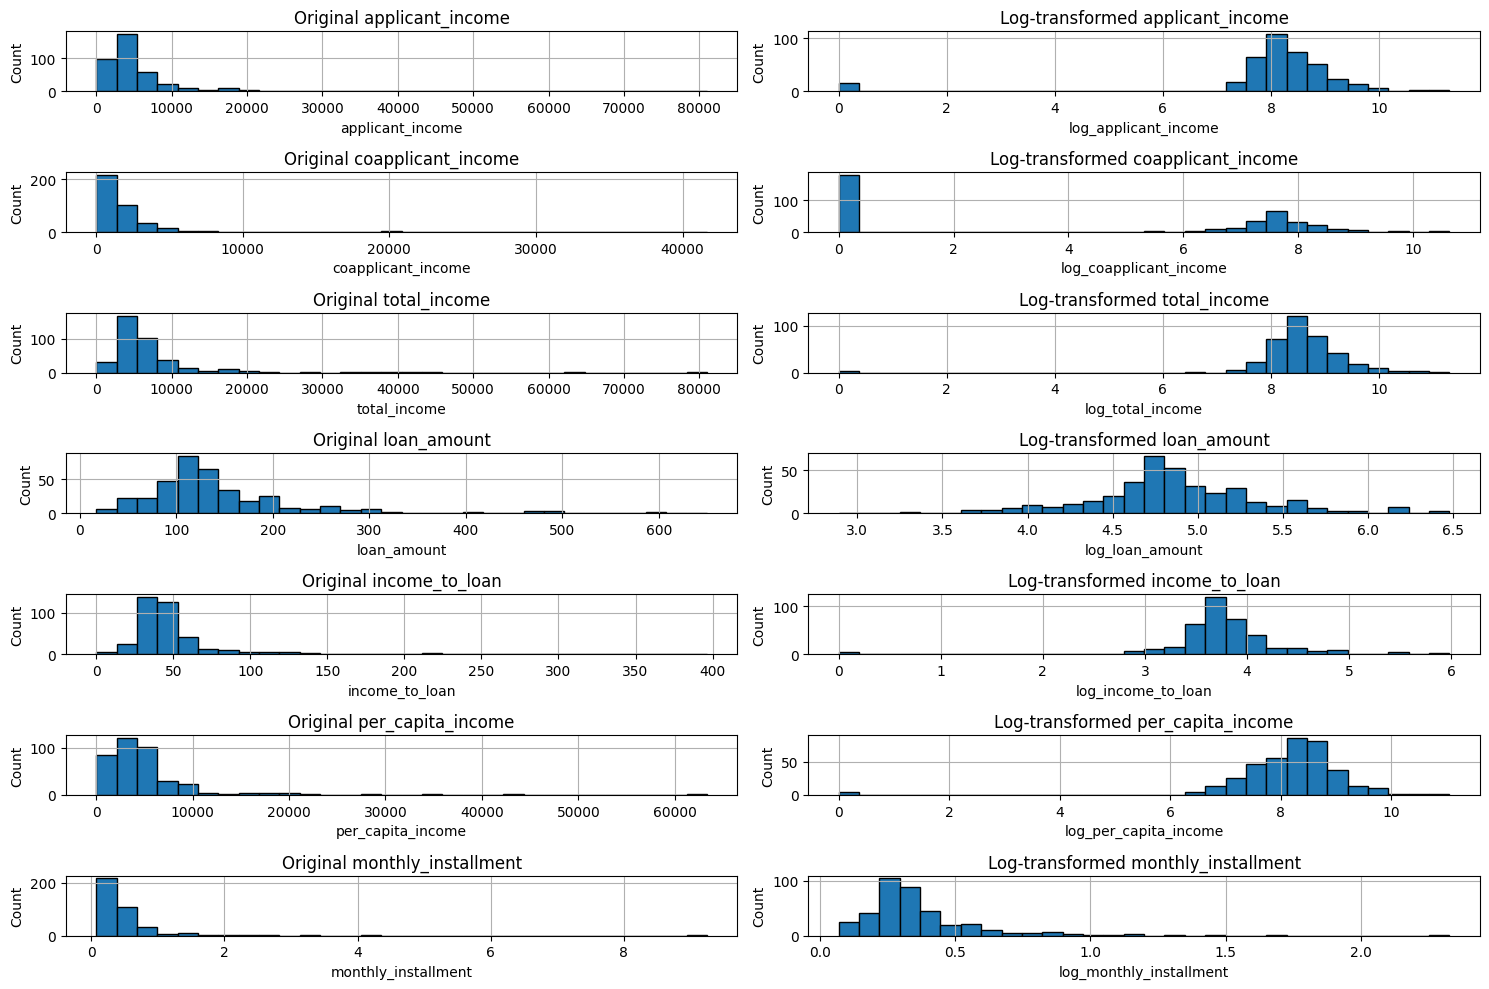

In [ ]:
import matplotlib.pyplot as plt

log_features = ["applicant_income", "coapplicant_income",
                "total_income", "loan_amount", "income_to_loan", "per_capita_income", 'monthly_installment']

plt.figure(figsize=(15, 10))

for i, col in enumerate(log_features, 1):
    plt.subplot(len(log_features), 2, 2*i-1)
    X_train[col].hist(bins=30, edgecolor="black")
    plt.title(f"Original {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.subplot(len(log_features), 2, 2*i)
    X_train["log_" + col].hist(bins=30, edgecolor="black")
    plt.title(f"Log-transformed {col}")
    plt.xlabel("log_" + col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


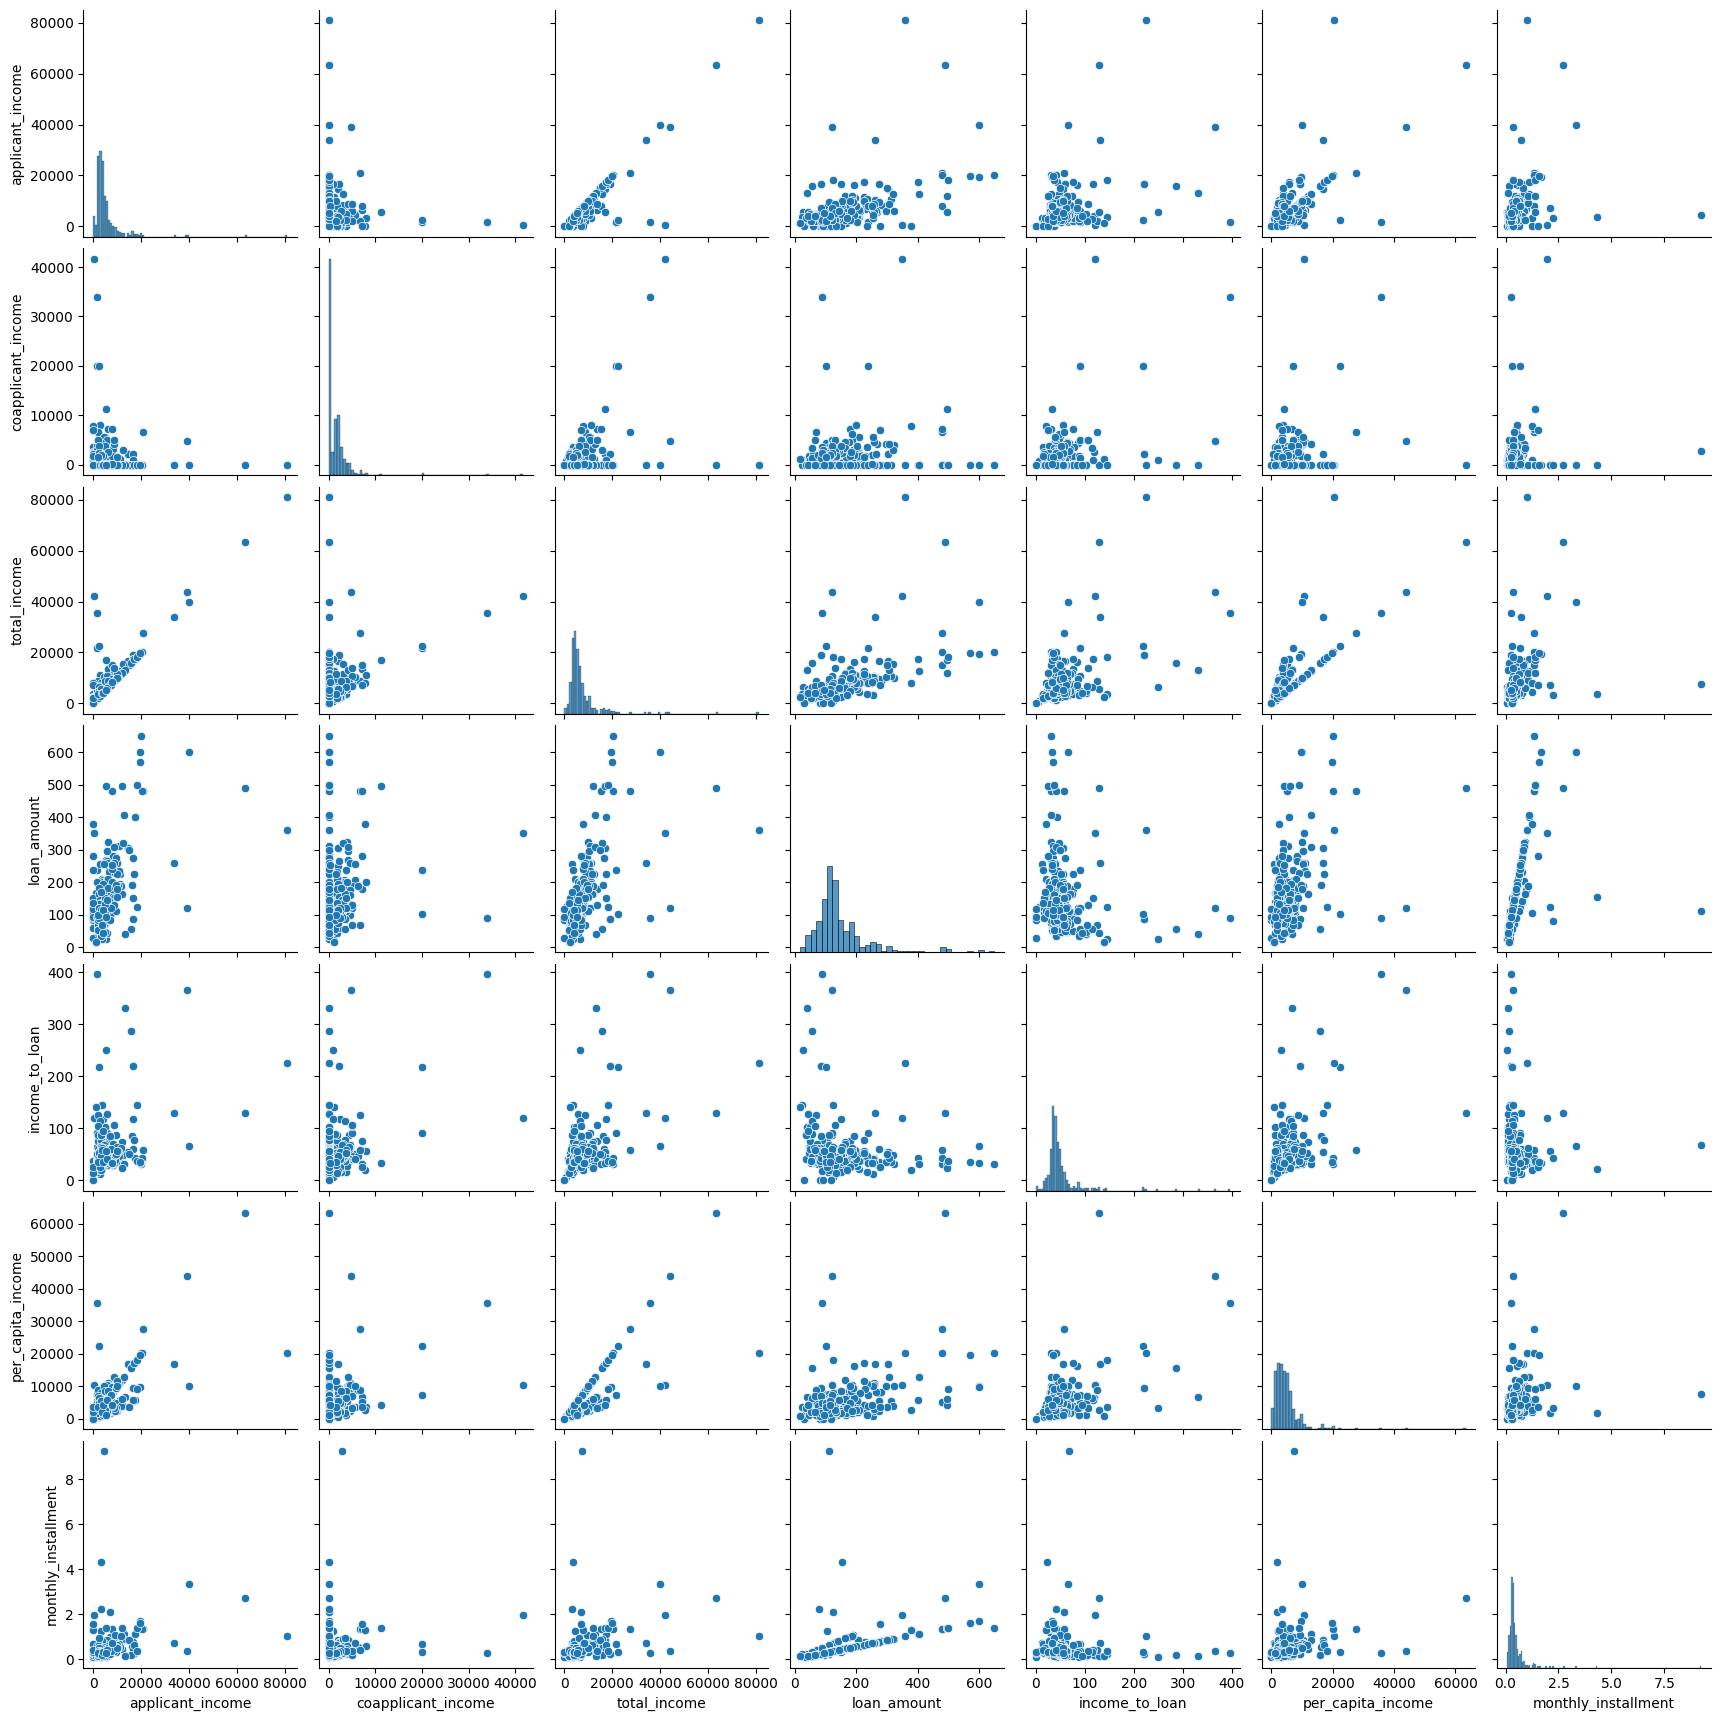

In [ ]:
sns.pairplot(X_train[log_features])
plt.show()

In [ ]:
X_train.head()

,applicant_income,coapplicant_income,loan_amount,loan_amount_term,dependents,gender,married,education,self_employed,credit_history,...,income_to_loan,monthly_installment,per_capita_income,log_applicant_income,log_coapplicant_income,log_loan_amount,log_total_income,log_income_to_loan,log_per_capita_income,log_monthly_installment
382,2699.0,2785.0,96.0,360.0,0,1.0,0.0,0.0,0.0,1.0,...,57.125,0.266667,5484.0,7.901007,7.932362,4.574711,8.609772,4.062596,8.609772,0.236389
67,3333.0,2166.0,130.0,360.0,3,1.0,1.0,0.0,1.0,1.0,...,42.3,0.361111,1374.75,8.111928,7.681099,4.875197,8.612503,3.768153,7.226754,0.308301
122,9538.0,0.0,187.0,360.0,1,1.0,1.0,1.0,0.0,1.0,...,51.005348,0.519444,4769.0,9.163144,0.000000,5.236442,9.163144,3.951347,8.470102,0.418345
401,6065.0,2004.0,250.0,360.0,1,1.0,1.0,1.0,0.0,1.0,...,32.276,0.694444,4034.5,8.710455,7.603399,5.525453,8.995909,3.504836,8.302885,0.527355
58,7100.0,0.0,125.0,60.0,3,1.0,1.0,0.0,1.0,1.0,...,56.8,2.083333,1775.0,8.867991,0.000000,4.836282,8.867991,4.056989,7.482119,1.126011


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'applicant_income', 'coapplicant_income', 'total_income',
    'loan_amount', 'income_to_loan', 'per_capita_income', 'monthly_installment',
    'log_applicant_income', 'log_coapplicant_income', 'log_total_income',
    'log_loan_amount', 'log_income_to_loan', 'log_per_capita_income',
    'log_monthly_installment'
]

scaler = StandardScaler()

X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_scaled[num_cols])


# Model Training and Basic Evaluation

## Model Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import numpy as np
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=5000, class_weight="balanced"),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(random_state=42, n_estimators=400, class_weight="balanced"),
    "KNN":                 KNeighborsClassifier(n_neighbors=11),
    "SVM":                 SVC(random_state=42, probability=True, class_weight="balanced"),
    "Naive Bayes":         GaussianNB(),
}

use_scaled = {"Logistic Regression", "KNN", "SVM", "Naive Bayes"}

y_tr, y_te = y_train, y_test


def compute_auc(model, X, y_true):
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X)
            if proba.shape[1] == 2:
                return roc_auc_score(y_true, proba[:, 1])
            else:
                return roc_auc_score(y_true, proba, multi_class="ovr")
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X)
            if scores.ndim == 1:
                return roc_auc_score(y_true, scores)
            else:
                return roc_auc_score(y_true, scores, multi_class="ovr")
        else:
            return None
    except Exception:
        return None


results = {}

for name, model in models.items():
    Xtr = X_train_scaled if name in use_scaled else X_train_raw
    Xte = X_test_scaled  if name in use_scaled else X_test_raw

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)


    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_te, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_te, y_pred, average="macro", zero_division=0)
    auc  = compute_auc(model, Xte, y_te)

    results[name] = {
        "Accuracy": acc,
        "Precision (macro)": prec,
        "Recall (macro)": rec,
        "F1 (macro)": f1,
        "ROC AUC": auc
    }

results_df = pd.DataFrame(results).T.sort_values(by=["F1 (macro)","ROC AUC","Accuracy"], ascending=False)
display(results_df.style.format("{:.3f}"))


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC AUC
Random Forest,0.812,0.771,0.726,0.743,0.796
Naive Bayes,0.792,0.739,0.700,0.714,0.743
Logistic Regression,0.750,0.700,0.732,0.709,0.742
Decision Tree,0.750,0.687,0.696,0.691,0.696
SVM,0.698,0.508,0.503,0.469,0.379
KNN,0.729,0.617,0.512,0.456,0.580


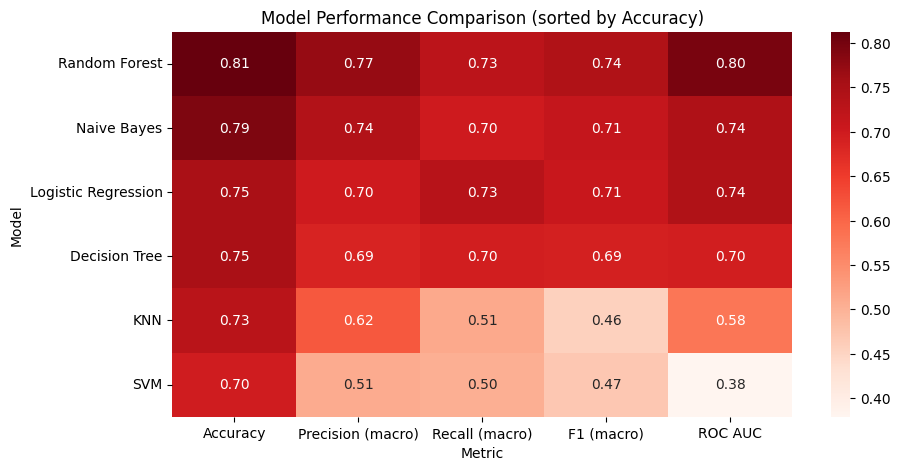

In [ ]:
sort_metric = 'Accuracy'
results_sorted = results_df.sort_values(by=sort_metric, ascending=False)

plt.figure(figsize=(10,5))
sns.heatmap(results_sorted, annot=True, cmap='Reds', fmt='.2f')
plt.title(f'Model Performance Comparison (sorted by {sort_metric})')
plt.ylabel('Model')
plt.xlabel('Metric')
plt.show()



Classification report – Random Forest:
              precision    recall  f1-score   support

         0.0      0.750     0.462     0.571        26
         1.0      0.825     0.943     0.880        70

    accuracy                          0.812        96
   macro avg      0.787     0.702     0.726        96
weighted avg      0.805     0.812     0.796        96



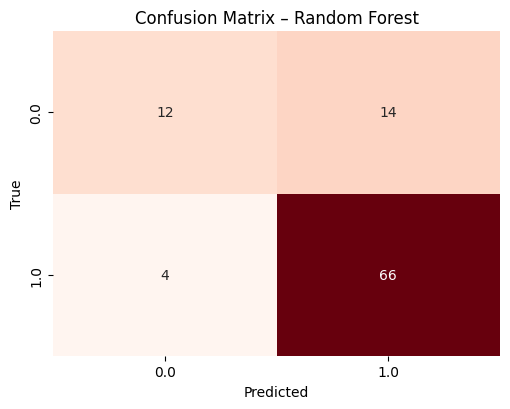

ROC AUC (Random Forest): 0.751


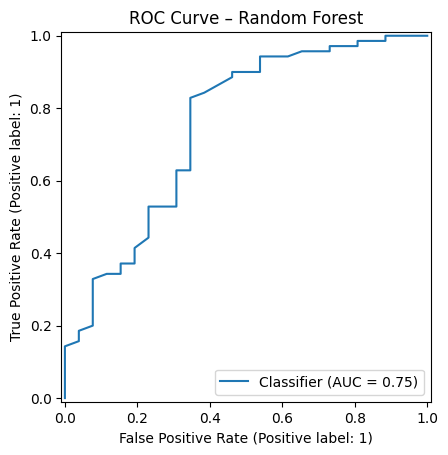

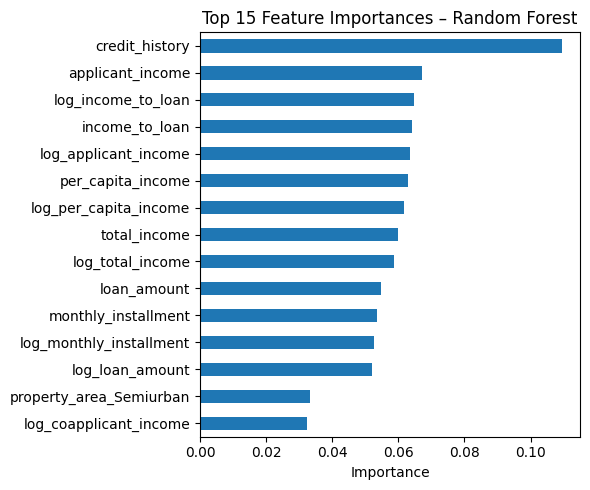

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

rf_model = models['Random Forest']

y_pred_rf = rf_model.predict(Xte)

print("Classification report – Random Forest:")
print(classification_report(y_te, y_pred_rf, digits=3))

labels = np.unique(y_te)
cm = confusion_matrix(y_te, y_pred_rf, labels=labels)

plt.figure(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Random Forest')
plt.tight_layout()
plt.show()

try:
    if hasattr(rf_model, "predict_proba") and len(np.unique(y_te)) == 2:
        y_score = rf_model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_te, y_score)
        print(f"ROC AUC (Random Forest): {auc:.3f}")
        RocCurveDisplay.from_predictions(y_te, y_score)
        plt.title('ROC Curve – Random Forest')
        plt.show()
except Exception as e:
    print("ROC/AUC nicht berechenbar:", e)


try:
    importances = rf_model.feature_importances_
    feat_names = getattr(Xtr, "columns", None)
    if feat_names is None:
        feat_names = [f"feat_{i}" for i in range(importances.shape[0])]

    top = (pd.Series(importances, index=feat_names)
             .sort_values(ascending=False)
             .head(15))

    plt.figure(figsize=(6, 5))
    top[::-1].plot(kind='barh')
    plt.title('Top 15 Feature Importances – Random Forest')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Feature-Importances nicht verfügbar:", e)


## Parameter-Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=800,
    random_state=42
)


best_rf.fit(Xtr, y_tr)




RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=800, random_state=42)

## Threshold-Tuning

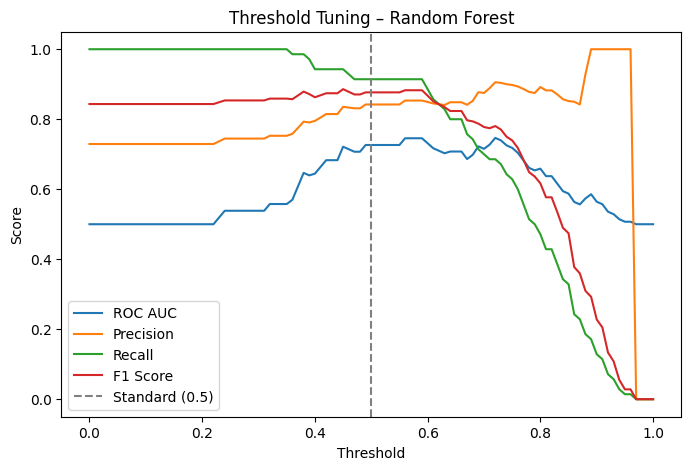

Bester Threshold nach F1: 0.45


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

y_proba = best_rf.predict_proba(Xte)[:, 1]

thresholds = np.linspace(0, 1, 101)
scores = []

for t in thresholds:
    y_pred_thr = (y_proba >= t).astype(int)
    scores.append({
        "threshold": t,
        "roc_auc": roc_auc_score(y_te, y_pred_thr),
        "precision": precision_score(y_te, y_pred_thr, zero_division=0),
        "recall": recall_score(y_te, y_pred_thr, zero_division=0),
        "f1": f1_score(y_te, y_pred_thr, zero_division=0),
    })

scores_df = pd.DataFrame(scores)

plt.figure(figsize=(8,5))
plt.plot(scores_df["threshold"], scores_df["roc_auc"], label="ROC AUC")
plt.plot(scores_df["threshold"], scores_df["precision"], label="Precision")
plt.plot(scores_df["threshold"], scores_df["recall"], label="Recall")
plt.plot(scores_df["threshold"], scores_df["f1"], label="F1 Score")
plt.axvline(0.5, color="gray", linestyle="--", label="Standard (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning – Random Forest")
plt.legend()
plt.show()

best_thr = scores_df.loc[scores_df["f1"].idxmax(), "threshold"]
print(f"Bester Threshold nach F1: {best_thr:.2f}")


Classification Report (Random Forest, Threshold 0.45):
              precision    recall  f1-score   support

         0.0       0.76      0.50      0.60        26
         1.0       0.84      0.94      0.89        70

    accuracy                           0.82        96
   macro avg       0.80      0.72      0.75        96
weighted avg       0.82      0.82      0.81        96



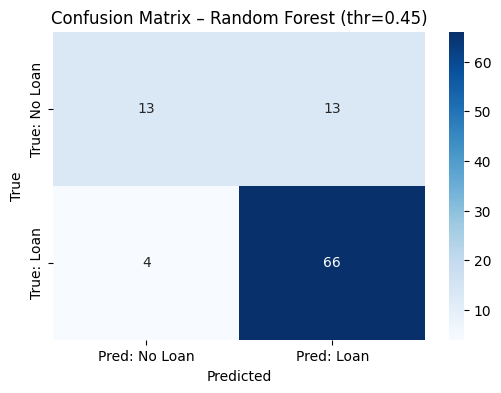

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_thr = (y_proba >= best_thr).astype(int)

y_pred_RF_best_thr_045 = y_pred_thr

print("Classification Report (Random Forest, Threshold {:.2f}):".format(best_thr))
print(classification_report(y_te, y_pred_thr))

conf_matrix = confusion_matrix(y_te, y_pred_thr)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Loan', 'Pred: Loan'],
            yticklabels=['True: No Loan', 'True: Loan'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – Random Forest (thr={best_thr:.2f})")
plt.show()



=== Klassifikationsreport bei Threshold 0.353 ===
              precision    recall  f1-score   support

         0.0       1.00      0.12      0.21        26
         1.0       0.75      1.00      0.86        70

    accuracy                           0.76        96
   macro avg       0.88      0.56      0.53        96
weighted avg       0.82      0.76      0.68        96



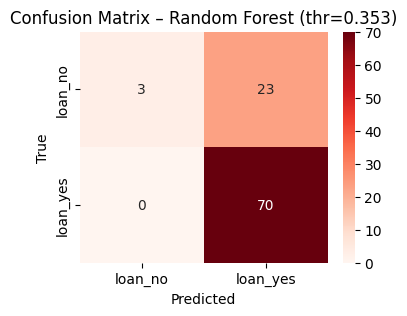


=== Klassifikationsreport bei Threshold 0.395 ===
              precision    recall  f1-score   support

         0.0       0.82      0.35      0.49        26
         1.0       0.80      0.97      0.88        70

    accuracy                           0.80        96
   macro avg       0.81      0.66      0.68        96
weighted avg       0.80      0.80      0.77        96



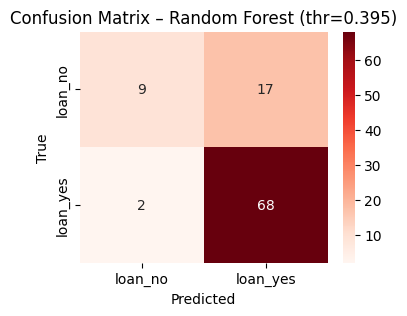


Vergleich der Thresholds:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Threshold 0.353,0.760417,0.752688,1.000000,0.858896,0.77967
Threshold 0.395,0.802083,0.800000,0.971429,0.877419,0.77967


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


thresholds = [0.353, 0.395]
results_thr = {}

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)

    results_thr[f"Threshold {thr}"] = {
        "Accuracy": accuracy_score(y_te, y_pred_thr),
        "Precision": precision_score(y_te, y_pred_thr),
        "Recall": recall_score(y_te, y_pred_thr),
        "F1 Score": f1_score(y_te, y_pred_thr),
        "ROC AUC": roc_auc_score(y_te, y_proba)
    }

    print(f"\n=== Klassifikationsreport bei Threshold {thr} ===")
    print(classification_report(y_te, y_pred_thr))

    cm = confusion_matrix(y_te, y_pred_thr)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Reds",
                xticklabels=["loan_no","loan_yes"],
                yticklabels=["loan_no","loan_yes"])
    plt.title(f"Confusion Matrix – Random Forest (thr={thr})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


results_thr_df = pd.DataFrame(results_thr).T
print("\nVergleich der Thresholds:")
display(results_thr_df)


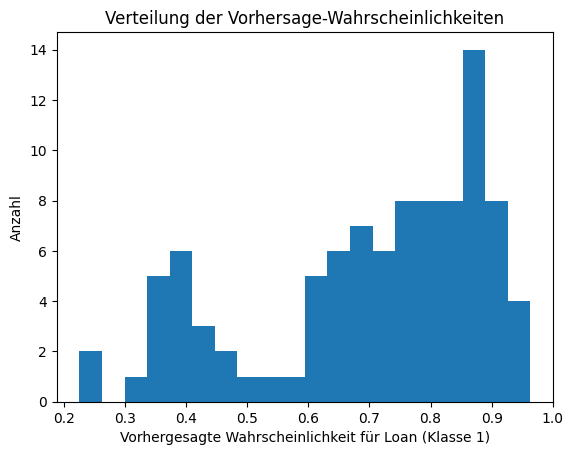

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=20)
plt.xlabel("Vorhergesagte Wahrscheinlichkeit für Loan (Klasse 1)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Vorhersage-Wahrscheinlichkeiten")
plt.show()


## Random Forest Balanced plus Threshold-Tuning

In [ ]:
obj_cols_tr = Xtr.select_dtypes('object').columns
obj_cols_te = Xte.select_dtypes('object').columns
for c in set(obj_cols_tr) | set(obj_cols_te):
    Xtr[c] = pd.to_numeric(Xtr[c], errors='coerce')
    Xte[c]  = pd.to_numeric(Xte[c],  errors='coerce')


=== 5-Fold CV (mean ± std) ===


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC AUC
3,XGBoost,0.786 ± 0.050,0.748 ± 0.079,0.686 ± 0.053,0.702 ± 0.060,0.720 ± 0.060
1,RF_balanced,0.788 ± 0.058,0.743 ± 0.097,0.682 ± 0.072,0.700 ± 0.082,0.734 ± 0.082
0,RF,0.801 ± 0.045,0.782 ± 0.081,0.677 ± 0.060,0.698 ± 0.071,0.737 ± 0.080
2,GradBoost,0.783 ± 0.063,0.739 ± 0.107,0.676 ± 0.081,0.691 ± 0.090,0.718 ± 0.061
4,LightGBM,0.765 ± 0.059,0.709 ± 0.090,0.669 ± 0.067,0.681 ± 0.073,0.720 ± 0.063



=== Test-Set Evaluation – XGBoost (thr=0.5) ===
              precision    recall  f1-score   support

         0.0      0.545     0.462     0.500        26
         1.0      0.811     0.857     0.833        70

    accuracy                          0.750        96
   macro avg      0.678     0.659     0.667        96
weighted avg      0.739     0.750     0.743        96

ROC AUC: 0.776


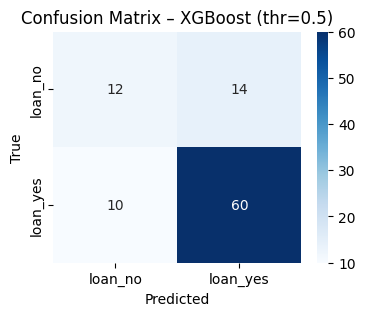


(Optional) Bester Threshold auf dem TEST (nur zur Illustration): t*=0.09, F1=0.868


In [ ]:
# === 0) Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

xgb_available, lgb_available = False, False
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    pass

try:
    from lightgbm import LGBMClassifier
    lgb_available = True
except Exception:
    pass

best_rf_params = {
    "n_estimators": 800,
    "max_depth": 12,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1
}


models = {
    "RF": RandomForestClassifier(
        **best_rf_params
    ),
    "RF_balanced": RandomForestClassifier(
        **best_rf_params, class_weight="balanced"

    ),
    "GradBoost": GradientBoostingClassifier(random_state=42)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.06,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1
    )

if lgb_available:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=800, max_depth=-1, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9, learning_rate=0.05,
        random_state=42, n_jobs=-1
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "acc": "accuracy",
    "prec_macro": "precision_macro",
    "rec_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
}

def mean_std_str(x):
    return f"{np.mean(x):.3f} ± {np.std(x):.3f}"

rows = []
cv_raw = {}

for name, clf in models.items():
    cv_res = cross_validate(
        clf, Xtr, y_tr,
        cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1
    )
    cv_raw[name] = cv_res
    rows.append({
        "Model": name,
        "Accuracy": mean_std_str(cv_res["test_acc"]),
        "Precision (macro)": mean_std_str(cv_res["test_prec_macro"]),
        "Recall (macro)": mean_std_str(cv_res["test_rec_macro"]),
        "F1 (macro)": mean_std_str(cv_res["test_f1_macro"]),
        "ROC AUC": mean_std_str(cv_res["test_roc_auc"]),
        "_f1_mean": np.mean(cv_res["test_f1_macro"]),
    })

cv_table = pd.DataFrame(rows).sort_values("_f1_mean", ascending=False).drop(columns=["_f1_mean"])
print("=== 5-Fold CV (mean ± std) ===")
display(cv_table)

best_name = pd.DataFrame(rows).sort_values("_f1_mean", ascending=False).iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(Xtr, y_tr)

y_pred = best_model.predict(Xte)
try:
    y_proba = best_model.predict_proba(Xte)[:, 1]
except Exception:
    y_proba = None

print(f"\n=== Test-Set Evaluation – {best_name} (thr=0.5) ===")
print(classification_report(y_te, y_pred, digits=3))
if y_proba is not None:
    print("ROC AUC:", f"{roc_auc_score(y_te, y_proba):.3f}")

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["loan_no", "loan_yes"],
            yticklabels=["loan_no", "loan_yes"])
plt.title(f"Confusion Matrix – {best_name} (thr=0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

def best_threshold(y_true, y_prob, metric="f1"):
    ts = np.linspace(0, 1, 401)
    scores = []
    for t in ts:
        yp = (y_prob >= t).astype(int)
        if metric == "f1":
            s = f1_score(y_true, yp)
        elif metric == "recall":
            s = recall_score(y_true, yp)
        elif metric == "precision":
            s = precision_score(y_true, yp)
        else:
            raise ValueError("metric must be 'f1', 'recall' or 'precision'")
        scores.append(s)
    i = int(np.argmax(scores))
    return ts[i], scores[i]

if y_proba is not None:
    t_star, s_star = best_threshold(y_te, y_proba, metric="f1")
    print(f"\n(Optional) Bester Threshold auf dem TEST (nur zur Illustration): t*={t_star:.2f}, F1={s_star:.3f}")



              precision    recall  f1-score   support

         0.0       0.68      0.58      0.62        26
         1.0       0.85      0.90      0.88        70

    accuracy                           0.81        96
   macro avg       0.77      0.74      0.75        96
weighted avg       0.81      0.81      0.81        96



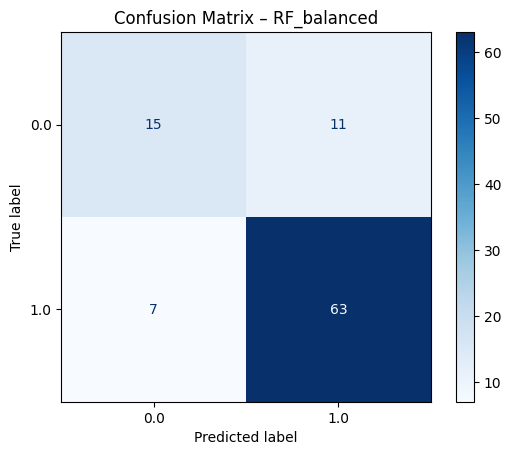

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
rf_balanced = models["RF_balanced"]
rf_balanced.fit(Xtr, y_tr)

y_pred_bal = rf_balanced.predict(Xte)


print(classification_report(y_te, y_pred_bal))


cm_bal = confusion_matrix(y_te, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=rf_balanced.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – RF_balanced")
plt.show()


## Threshold-Tuning for RF Balanced

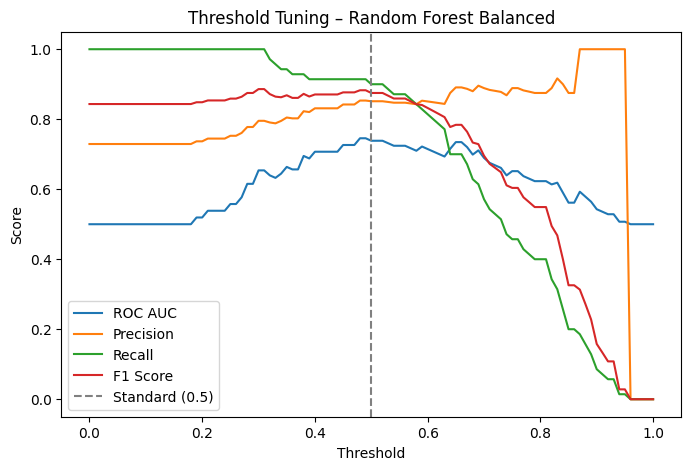

Bester Threshold nach F1: 0.30


In [ ]:

y_proba = rf_balanced.predict_proba(Xte)[:, 1]

thresholds = np.linspace(0, 1, 101)
scores = []

for t in thresholds:
    y_pred_thr = (y_proba >= t).astype(int)
    scores.append({
        "threshold": t,
        "roc_auc": roc_auc_score(y_te, y_pred_thr),
        "precision": precision_score(y_te, y_pred_thr, zero_division=0),
        "recall": recall_score(y_te, y_pred_thr, zero_division=0),
        "f1": f1_score(y_te, y_pred_thr, zero_division=0),
    })

scores_df = pd.DataFrame(scores)

plt.figure(figsize=(8,5))
plt.plot(scores_df["threshold"], scores_df["roc_auc"], label="ROC AUC")
plt.plot(scores_df["threshold"], scores_df["precision"], label="Precision")
plt.plot(scores_df["threshold"], scores_df["recall"], label="Recall")
plt.plot(scores_df["threshold"], scores_df["f1"], label="F1 Score")
plt.axvline(0.5, color="gray", linestyle="--", label="Standard (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning – Random Forest Balanced")
plt.legend()
plt.show()

best_thr = scores_df.loc[scores_df["f1"].idxmax(), "threshold"]
print(f"Bester Threshold nach F1: {best_thr:.2f}")

Classification Report (Random Forest, Threshold 0.30):
              precision    recall  f1-score   support

         0.0       1.00      0.31      0.47        26
         1.0       0.80      1.00      0.89        70

    accuracy                           0.81        96
   macro avg       0.90      0.65      0.68        96
weighted avg       0.85      0.81      0.77        96



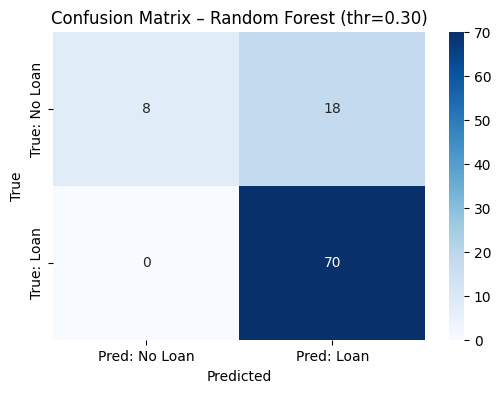

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_thr = (y_proba >= best_thr).astype(int)

# Classification Report
print("Classification Report (Random Forest, Threshold {:.2f}):".format(best_thr))
print(classification_report(y_te, y_pred_thr))

# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred_thr)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Loan', 'Pred: Loan'],
            yticklabels=['True: No Loan', 'True: Loan'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – Random Forest (thr={best_thr:.2f})")
plt.show()


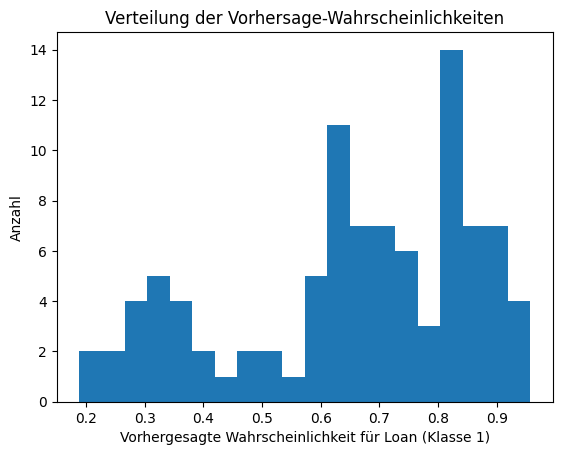

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=20)
plt.xlabel("Vorhergesagte Wahrscheinlichkeit für Loan (Klasse 1)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Vorhersage-Wahrscheinlichkeiten")
plt.show()



=== Klassifikationsreport bei Threshold 0.65 ===
              precision    recall  f1-score   support

         0.0       0.49      0.77      0.60        26
         1.0       0.89      0.70      0.78        70

    accuracy                           0.72        96
   macro avg       0.69      0.73      0.69        96
weighted avg       0.78      0.72      0.73        96



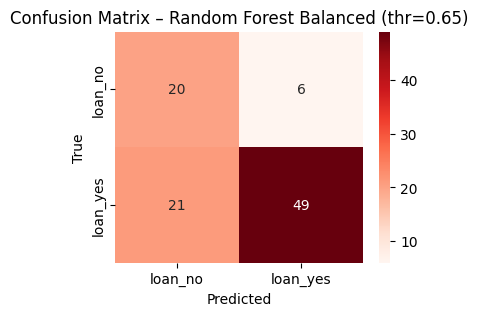


=== Klassifikationsreport bei Threshold 0.49 ===
              precision    recall  f1-score   support

         0.0       0.71      0.58      0.64        26
         1.0       0.85      0.91      0.88        70

    accuracy                           0.82        96
   macro avg       0.78      0.75      0.76        96
weighted avg       0.82      0.82      0.82        96



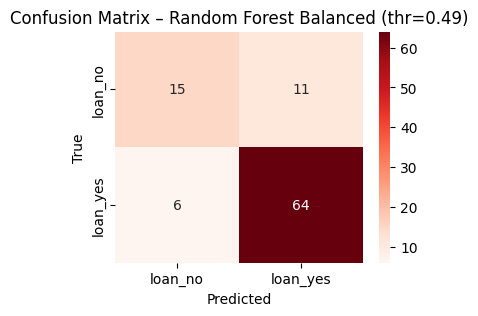


Vergleich der Thresholds:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Threshold 0.65,0.718750,0.890909,0.700000,0.784000,0.785165
Threshold 0.49,0.822917,0.853333,0.914286,0.882759,0.785165


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

thresholds = [0.65, 0.49]
results_thr = {}
y_preds_thr = {}


for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)

    y_preds_thr[f"RF_balanced_thr_{thr}"] = y_pred_thr

    results_thr[f"Threshold {thr}"] = {
        "Accuracy": accuracy_score(y_te, y_pred_thr),
        "Precision": precision_score(y_te, y_pred_thr),
        "Recall": recall_score(y_te, y_pred_thr),
        "F1 Score": f1_score(y_te, y_pred_thr),
        "ROC AUC": roc_auc_score(y_te, y_proba)
    }

    print(f"\n=== Klassifikationsreport bei Threshold {thr} ===")
    print(classification_report(y_te, y_pred_thr))

    cm = confusion_matrix(y_te, y_pred_thr)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Reds",
                xticklabels=["loan_no","loan_yes"],
                yticklabels=["loan_no","loan_yes"])
    plt.title(f"Confusion Matrix – Random Forest Balanced (thr={thr})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

y_pred_thr_049 = y_preds_thr["RF_balanced_thr_0.49"]
y_pred_thr_065 = y_preds_thr["RF_balanced_thr_0.65"]

results_thr_df = pd.DataFrame(results_thr).T
print("\nVergleich der Thresholds:")
display(results_thr_df)

## Threshold-Table for RF Balanced

,threshold,accuracy,precision,recall,f1
0,0.20,0.739583,0.736842,1.000000,0.848485
1,0.25,0.760417,0.752688,1.000000,0.858896
2,0.30,0.812500,0.795455,1.000000,0.886076
3,0.35,0.791667,0.804878,0.942857,0.868421
4,0.40,0.802083,0.831169,0.914286,0.870748
5,0.45,0.812500,0.842105,0.914286,0.876712
6,0.50,0.812500,0.851351,0.900000,0.875000
7,0.55,0.791667,0.847222,0.871429,0.859155
8,0.60,0.760417,0.850746,0.814286,0.832117
9,0.65,0.718750,0.890909,0.700000,0.784000



Bester Threshold (nach F1): 0.30  |  F1=0.886


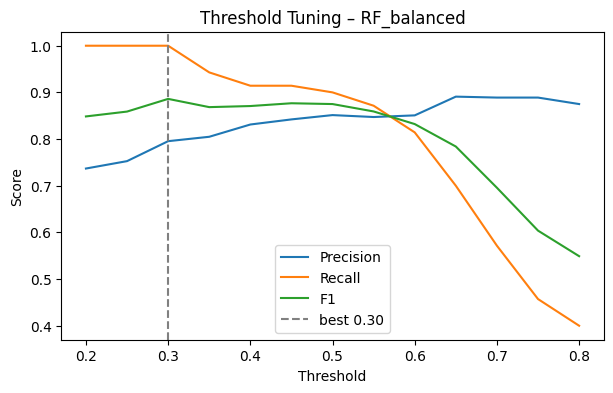

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_proba = rf_balanced.predict_proba(Xte)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.05)
rows = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy":  accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall":    recall_score(y_te, y_pred, zero_division=0),
        "f1":        f1_score(y_te, y_pred, zero_division=0)
    })

thr_df = pd.DataFrame(rows)
display(thr_df)

best_thr = float(thr_df.loc[thr_df["f1"].idxmax(), "threshold"])
print(f"\nBester Threshold (nach F1): {best_thr:.2f}  |  F1={thr_df['f1'].max():.3f}")


plt.figure(figsize=(7,4))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"],    label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"],        label="F1")
plt.axvline(best_thr, color="gray", linestyle="--", label=f"best {best_thr:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Threshold Tuning – RF_balanced"); plt.legend()
plt.show()




## XGBoost

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Beste XGB-Parameter: {'subsample': np.float64(0.8), 'scale_pos_weight': np.float64(0.3776978417266187), 'reg_lambda': np.float64(100.0), 'reg_alpha': 0, 'n_estimators': np.int64(200), 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': np.float64(0.03162277660168381), 'gamma': 2, 'colsample_bytree': np.float64(1.0)}
CV-F1 (mean ± std):   0.878 ±  0.016

=== XGBoost @ thr=0.50 (Test) ===
              precision    recall  f1-score   support

         0.0      0.750     0.462     0.571        26
         1.0      0.825     0.943     0.880        70

    accuracy                          0.812        96
   macro avg      0.787     0.702     0.726        96
weighted avg      0.805     0.812     0.796        96

ROC AUC: 0.7021978021978021


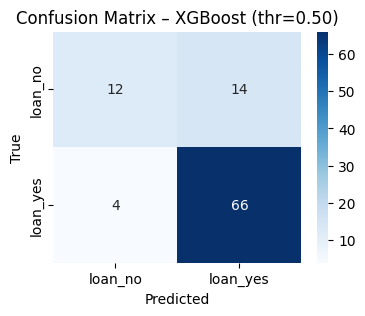


Bester Threshold (nach F1 auf Test):  0.53, F1= 0.880

=== XGBoost @ best thr (Test) ===
              precision    recall  f1-score   support

         0.0      0.750     0.462     0.571        26
         1.0      0.825     0.943     0.880        70

    accuracy                          0.812        96
   macro avg      0.787     0.702     0.726        96
weighted avg      0.805     0.812     0.796        96



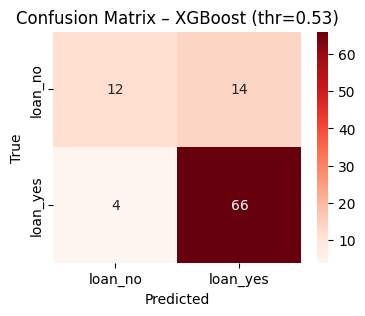

In [ ]:
# 1) Setup
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
scale_pos_weight = neg / max(pos, 1)

xgb = XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    enable_categorical=False
)

param_dist = {
    "n_estimators":     np.arange(200, 1001, 100),
    "max_depth":        [3,4,5,6,7,8],
    "learning_rate":    np.logspace(-3, -0.3, 10),
    "subsample":        np.linspace(0.6, 1.0, 5),
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "min_child_weight": [1, 2, 3, 5, 7, 10],
    "gamma":            [0, 0.5, 1, 2],
    "reg_lambda":       np.logspace(-2, 2, 8),
    "reg_alpha":        [0, 1e-3, 1e-2, 1e-1, 1],
    "scale_pos_weight": [scale_pos_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42,
    refit=True
)

rs.fit(Xtr, y_tr)

print("Beste XGB-Parameter:", rs.best_params_)
print("CV-F1 (mean ± std):  "
      f"{rs.best_score_: .3f} ± {rs.cv_results_['std_test_score'][rs.best_index_]: .3f}")

best_xgb = rs.best_estimator_

y_pred = best_xgb.predict(Xte)
y_proba = best_xgb.predict_proba(Xte)[:, 1]

print("\n=== XGBoost @ thr=0.50 (Test) ===")
print(classification_report(y_te, y_pred, digits=3))
print("ROC AUC:", roc_auc_score(y_te, y_proba))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["loan_no","loan_yes"],
            yticklabels=["loan_no","loan_yes"])
plt.title("Confusion Matrix – XGBoost (thr=0.50)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

prec, rec, thr = precision_recall_curve(y_te, y_proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
best_idx = np.argmax(f1s)
best_thr = max(min(thr[best_idx], 0.999), 0.001)

print(f"\nBester Threshold (nach F1 auf Test): {best_thr: .2f}, F1={f1s[best_idx]: .3f}")

y_pred_thr = (y_proba >= best_thr).astype(int)
print("\n=== XGBoost @ best thr (Test) ===")
print(classification_report(y_te, y_pred_thr, digits=3))

cm2 = confusion_matrix(y_te, y_pred_thr)
plt.figure(figsize=(4,3))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Reds",
            xticklabels=["loan_no","loan_yes"],
            yticklabels=["loan_no","loan_yes"])
plt.title(f"Confusion Matrix – XGBoost (thr={best_thr:.2f})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


,threshold,accuracy,precision,recall,f1
0,0.20,0.729167,0.729167,1.000000,0.843373
1,0.25,0.729167,0.729167,1.000000,0.843373
2,0.30,0.729167,0.729167,1.000000,0.843373
3,0.35,0.729167,0.729167,1.000000,0.843373
4,0.40,0.729167,0.729167,1.000000,0.843373
5,0.45,0.812500,0.825000,0.942857,0.880000
6,0.50,0.812500,0.825000,0.942857,0.880000
7,0.55,0.270833,0.000000,0.000000,0.000000
8,0.60,0.270833,0.000000,0.000000,0.000000
9,0.65,0.270833,0.000000,0.000000,0.000000



Bester Threshold (nach F1): 0.45  |  F1=0.880


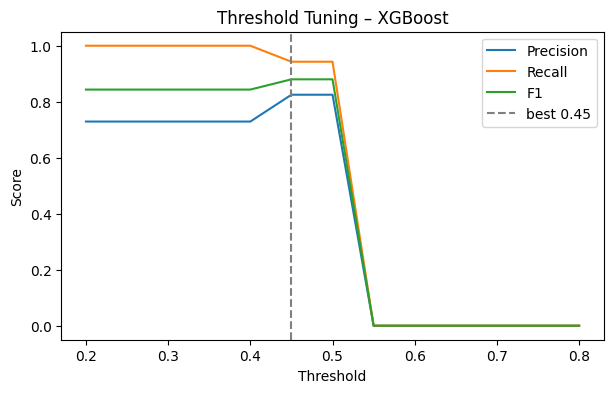


Classification Report (XGBoost, best thr):
              precision    recall  f1-score   support

         0.0      0.750     0.462     0.571        26
         1.0      0.825     0.943     0.880        70

    accuracy                          0.812        96
   macro avg      0.787     0.702     0.726        96
weighted avg      0.805     0.812     0.796        96



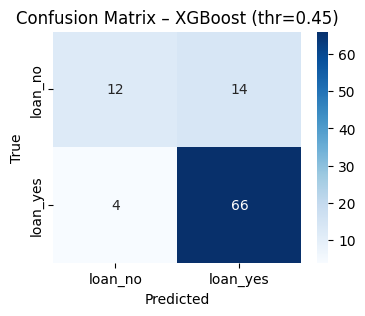

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


thresholds = np.arange(0.20, 0.81, 0.05)
rows = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy":  accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall":    recall_score(y_te, y_pred, zero_division=0),
        "f1":        f1_score(y_te, y_pred, zero_division=0)
    })

thr_df = pd.DataFrame(rows)
display(thr_df)

best_thr = float(thr_df.loc[thr_df["f1"].idxmax(), "threshold"])
print(f"\nBester Threshold (nach F1): {best_thr:.2f}  |  F1={thr_df['f1'].max():.3f}")

plt.figure(figsize=(7,4))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"],    label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"],        label="F1")
plt.axvline(best_thr, color="gray", linestyle="--", label=f"best {best_thr:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Threshold Tuning – XGBoost"); plt.legend()
plt.show()

y_pred_best = (y_proba >= best_thr).astype(int)
print("\nClassification Report (XGBoost, best thr):")
print(classification_report(y_te, y_pred_best, digits=3))

cm = confusion_matrix(y_te, y_pred_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["loan_no","loan_yes"], yticklabels=["loan_no","loan_yes"])
plt.title(f"Confusion Matrix – XGBoost (thr={best_thr:.2f})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Result

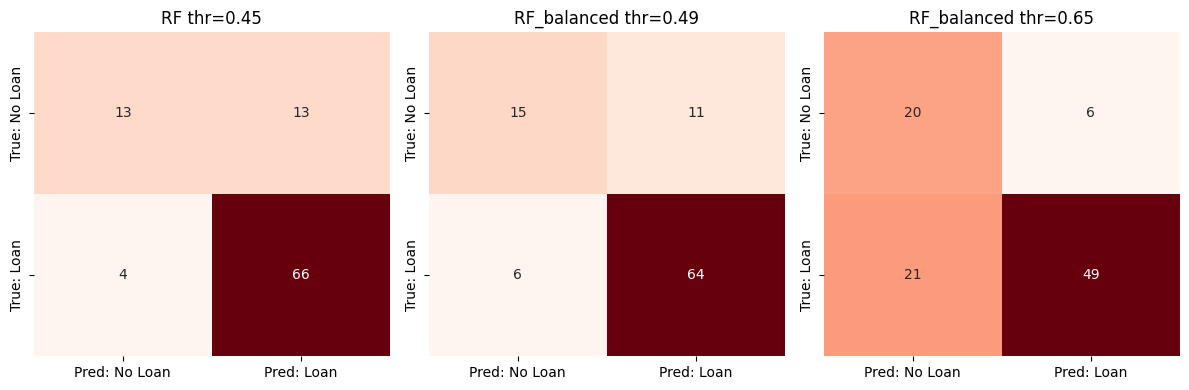

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

results = {
    "RF thr=0.45": (y_te, y_pred_RF_best_thr_045),
    "RF_balanced thr=0.49": (y_te, y_pred_thr_049),
    "RF_balanced thr=0.65": (y_te, y_pred_thr_065),
}

plt.figure(figsize=(12,4))

for i, (title, (y_true, y_pred)) in enumerate(results.items(), 1):
    cm = confusion_matrix(y_true, y_pred)
    plt.subplot(1, len(results), i)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Reds", cbar=False,
                xticklabels=["Pred: No Loan", "Pred: Loan"],
                yticklabels=["True: No Loan", "True: Loan"])
    plt.title(title)

plt.tight_layout()
plt.show()


## Conclusion
The Random Forest (balanced) and threshold tuning experiments demonstrate the trade-off between false positives (granting loans to risky clients) and false negatives (rejecting creditworthy clients).

A lower threshold (0.45) minimizes false negatives but increases the risk of false positives.

A medium threshold (0.49) achieves a balanced compromise.

A stricter threshold (0.65) strongly reduces false positives but at the cost of rejecting more good clients.

Overall, the results are consistent with typical credit scoring challenges. The final decision depends on the institution’s risk appetite: whether to prioritize minimizing defaults (false positives) or maximizing acceptance of good clients (reducing false negatives).